# **Computer vision handwriting classification project**

### **Imports**

In [1]:
# ============================================================
# IMPORTS
# ============================================================

import os
import time
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision import models
from torch import profiler

from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

from huggingface_hub import snapshot_download
import requests

### **Device**

In [ ]:
# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")

Device: cuda


### **Dataset**

In [ ]:
# ============================================================
# DATASET PATH
# ============================================================

dataset_path = snapshot_download(
    repo_id="InesBerdinas/calligraphy-classification-dataset",
    repo_type="dataset"
)

print(dataset_path)

In [ ]:
print(os.listdir(dataset_path))

['README.md', 'test', 'train', '.gitattributes', 'val']


In [ ]:
train_dir = os.path.join(dataset_path, "train")
val_dir = os.path.join(dataset_path, "val")
test_dir = os.path.join(dataset_path, "test")

### **Transformations**

In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

train_transforms = transforms.Compose([

    transforms.Resize((224, 224)),

    # --------------------------------------------------------
    # DATA AUGMENTATION
    # --------------------------------------------------------

    transforms.RandomRotation(5),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.02, 0.02)
    ),

    transforms.ToTensor(),

    # --------------------------------------------------------
    # NORMALIZATION
    # ImageNet statistics
    # --------------------------------------------------------

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# VALIDATION / TEST
# WITHOUT DATA AUGMENTATION
# ============================================================

val_test_transforms = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

### **Charge Dataset**

In [ ]:
# ============================================================
# DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(
    train_dir,
    transform=train_transforms
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=val_test_transforms
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=val_test_transforms
)

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# ============================================================
# CLASS NAMES
# ============================================================

class_names = train_dataset.classes

print(class_names)

['Persona_01', 'Persona_02', 'Persona_03', 'Persona_04', 'Persona_05']


### **View images**

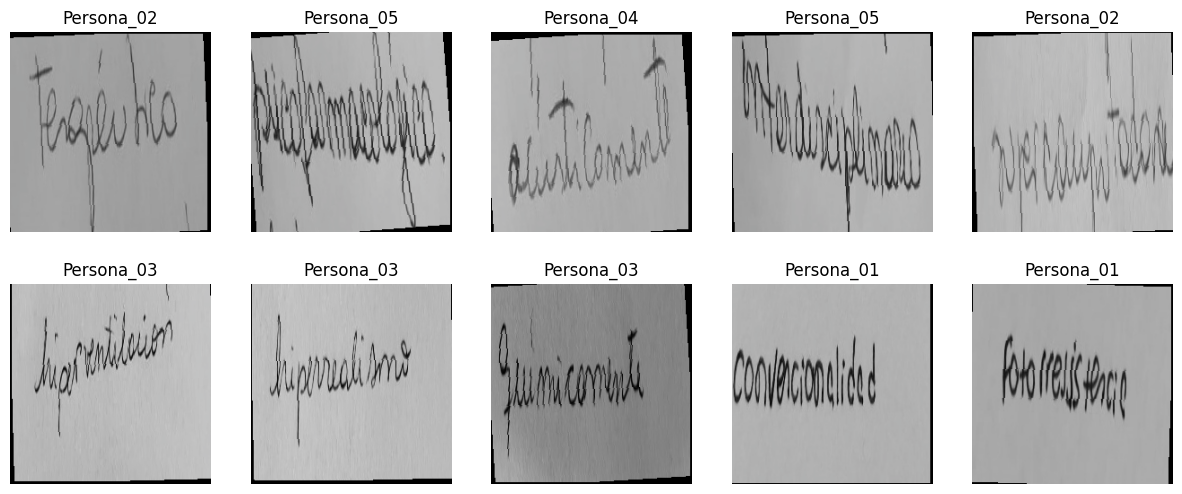

In [ ]:
# ============================================================
# VIEW DATASET
# ============================================================

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):

    img = images[i].permute(1, 2, 0).numpy()

    img = (
        img * np.array([0.229, 0.224, 0.225])
        + np.array([0.485, 0.456, 0.406])
    )

    img = np.clip(img, 0, 1)

    ax.imshow(img)

    ax.set_title(
        class_names[labels[i]]
    )

    ax.axis("off")

plt.show()

### **Creat Model**

In [ ]:
# ============================================================
# EFFICIENTNET-B0
# ============================================================

weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)

# ============================================================
# MODIFY CLASSIFIER
# ============================================================

num_classes = 5

model.classifier[1] = nn.Linear(
    in_features=1280,
    out_features=num_classes
)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 104MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

### **FEATURE EXTRACTION**

In [ ]:
# ============================================================
# FEATURE EXTRACTION
# ============================================================

# ------------------------------------------------------------
# FREEZE ALL LAYERS
# ------------------------------------------------------------

for param in model.parameters():

    param.requires_grad = False

# ------------------------------------------------------------
# UNFREEZE CLASSIFIER
# ------------------------------------------------------------

for param in model.classifier.parameters():

    param.requires_grad = True

# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(

    model.classifier.parameters(),

    lr=1e-3
)

### **Training Function**

In [ ]:
# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs
):

    train_losses = []
    val_losses = []

    train_accuracies = []
    val_accuracies = []

    best_model_wts = copy.deepcopy(
        model.state_dict()
    )

    best_acc = 0.0

    for epoch in range(epochs):

        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        running_loss = 0.0

        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

        train_loss = (
            running_loss / len(train_loader)
        )

        train_acc = (
            100 * correct / total
        )

        train_losses.append(train_loss)

        train_accuracies.append(train_acc)

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        val_running_loss = 0.0

        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_running_loss += loss.item()

                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)

                val_correct += (
                    predicted == labels
                ).sum().item()

        val_loss = (
            val_running_loss / len(val_loader)
        )

        val_acc = (
            100 * val_correct / val_total
        )

        val_losses.append(val_loss)

        val_accuracies.append(val_acc)

        # ====================================================
        # BEST MODEL
        # ====================================================

        if val_acc > best_acc:

            best_acc = val_acc

            best_model_wts = copy.deepcopy(
                model.state_dict()
            )

        # ====================================================
        # PRINT
        # ====================================================

        print(
            f"Epoch [{epoch+1}/{epochs}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.2f}%"
        )

    # ========================================================
    # LOAD BEST MODEL
    # ========================================================

    model.load_state_dict(best_model_wts)

    return (
        model,
        train_losses,
        val_losses,
        train_accuracies,
        val_accuracies
    )

### **Train Feature Extraction**

In [ ]:
# ============================================================
# TRAIN FEATURE EXTRACTION
# ============================================================

model, train_losses, val_losses, train_accs, val_accs = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    epochs=10
)

Epoch [1/10] | Train Loss: 1.2945 | Train Acc: 58.43% | Val Loss: 1.2487 | Val Acc: 58.67%
Epoch [2/10] | Train Loss: 0.8336 | Train Acc: 82.57% | Val Loss: 0.8688 | Val Acc: 72.00%
Epoch [3/10] | Train Loss: 0.6268 | Train Acc: 84.86% | Val Loss: 0.6873 | Val Acc: 82.00%
Epoch [4/10] | Train Loss: 0.5046 | Train Acc: 90.43% | Val Loss: 0.6441 | Val Acc: 82.67%
Epoch [5/10] | Train Loss: 0.4321 | Train Acc: 90.86% | Val Loss: 0.5853 | Val Acc: 82.67%
Epoch [6/10] | Train Loss: 0.3977 | Train Acc: 91.00% | Val Loss: 0.5440 | Val Acc: 84.00%
Epoch [7/10] | Train Loss: 0.3669 | Train Acc: 90.86% | Val Loss: 0.4982 | Val Acc: 84.67%
Epoch [8/10] | Train Loss: 0.3337 | Train Acc: 92.29% | Val Loss: 0.4572 | Val Acc: 86.00%
Epoch [9/10] | Train Loss: 0.3096 | Train Acc: 92.86% | Val Loss: 0.4413 | Val Acc: 82.67%
Epoch [10/10] | Train Loss: 0.3209 | Train Acc: 90.71% | Val Loss: 0.4084 | Val Acc: 87.33%


### **Curves**

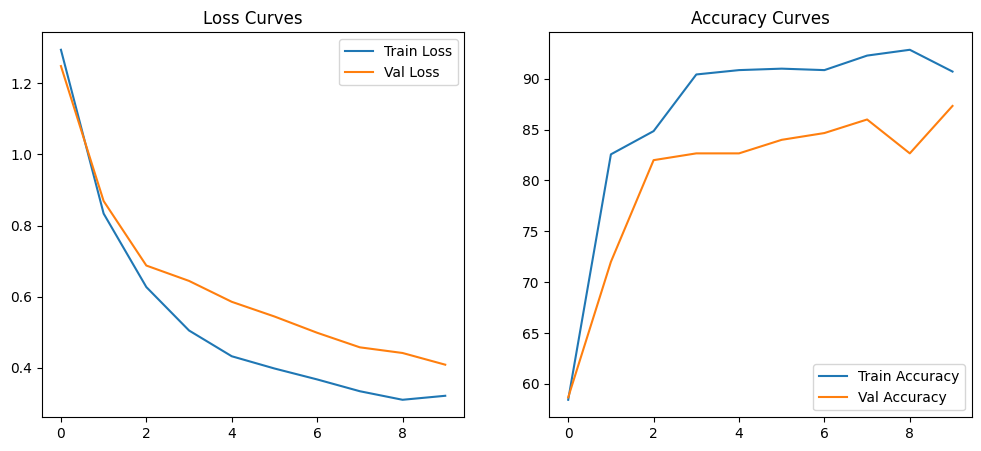

In [ ]:
# ============================================================
# CURVES
# ============================================================

plt.figure(figsize=(12,5))

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

plt.subplot(1,2,1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")

plt.legend()

plt.title("Loss Curves")

# ------------------------------------------------------------
# ACCURACY
# ------------------------------------------------------------

plt.subplot(1,2,2)

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")

plt.legend()

plt.title("Accuracy Curves")

plt.show()

### **Evaluation + Confusion Matrix**

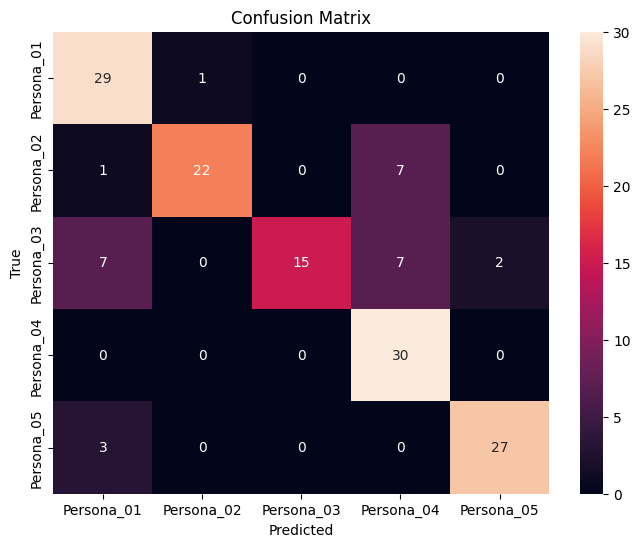

              precision    recall  f1-score   support

  Persona_01       0.72      0.97      0.83        30
  Persona_02       0.96      0.73      0.83        30
  Persona_03       1.00      0.48      0.65        31
  Persona_04       0.68      1.00      0.81        30
  Persona_05       0.93      0.90      0.92        30

    accuracy                           0.81       151
   macro avg       0.86      0.82      0.81       151
weighted avg       0.86      0.81      0.81       151



In [ ]:
# ============================================================
# EVALUATION
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=class_names,

    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Confusion Matrix")

plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

### **FINE TUNING**

In [ ]:
# ============================================================
# LOAD FEATURE EXTRACTION WEIGHTS
# ============================================================

weights = models.EfficientNet_B0_Weights.DEFAULT

model = models.efficientnet_b0(
    weights=weights
)

model.classifier[1] = nn.Linear(
    1280,
    num_classes
)


WEIGHTS_URL = (
    "https://raw.githubusercontent.com/"
    "InesBerdinas/calligraphy-classification/main/"
    "feature_extraction_weights.pth"
)

response = requests.get(WEIGHTS_URL)

with open(
    "feature_extraction_weights.pth",
    "wb"
) as f:
    f.write(response.content)

model.load_state_dict(
    torch.load(
        "feature_extraction_weights.pth",
        map_location=device
    )
)
model = model.to(device)

# ============================================================
# FREEZE EVERYTHING
# ============================================================

for param in model.parameters():

    param.requires_grad = False

# ============================================================
# UNFREEZE LAST BLOCK
# ============================================================

for param in model.features[-1].parameters():

    param.requires_grad = True

# ============================================================
# UNFREEZE CLASSIFIER
# ============================================================

for param in model.classifier.parameters():

    param.requires_grad = True

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.Adam(

    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),

    lr=1e-5
)

### **Train Fine Tuning**

In [ ]:
# ============================================================
# TRAIN FINE TUNING
# ============================================================

model, train_losses_ft, val_losses_ft, train_accs_ft, val_accs_ft = train_model(

    model=model,

    train_loader=train_loader,

    val_loader=val_loader,

    criterion=criterion,

    optimizer=optimizer,

    epochs=5
)

Epoch [1/5] | Train Loss: 0.2286 | Train Acc: 93.43% | Val Loss: 0.3248 | Val Acc: 88.00%
Epoch [2/5] | Train Loss: 0.2193 | Train Acc: 93.71% | Val Loss: 0.2952 | Val Acc: 88.67%
Epoch [3/5] | Train Loss: 0.2157 | Train Acc: 93.14% | Val Loss: 0.2895 | Val Acc: 91.33%
Epoch [4/5] | Train Loss: 0.1971 | Train Acc: 94.57% | Val Loss: 0.2683 | Val Acc: 91.33%
Epoch [5/5] | Train Loss: 0.1896 | Train Acc: 95.29% | Val Loss: 0.2570 | Val Acc: 92.67%


### **Fine Tuning Curves**

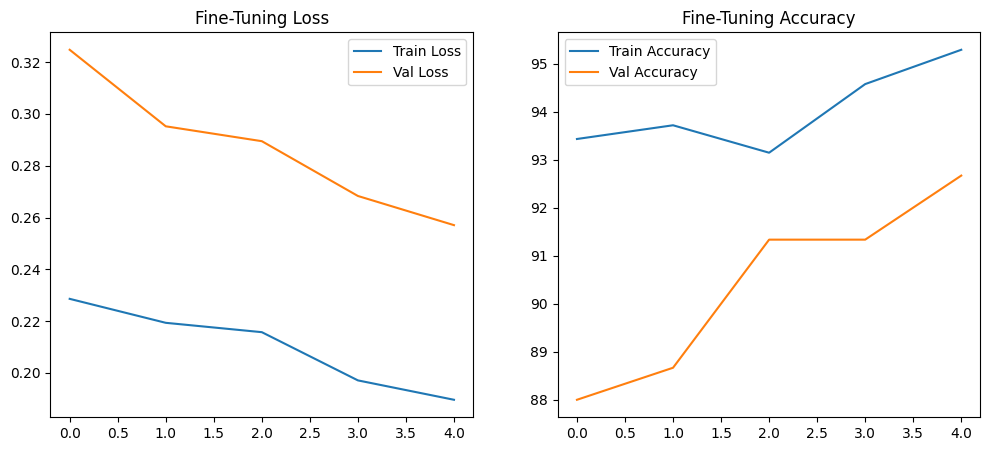

In [ ]:
# ============================================================
# FINE TUNING CURVES
# ============================================================

plt.figure(figsize=(12,5))

# ------------------------------------------------------------
# LOSS
# ------------------------------------------------------------

plt.subplot(1,2,1)

plt.plot(train_losses_ft, label="Train Loss")
plt.plot(val_losses_ft, label="Val Loss")

plt.legend()

plt.title("Fine-Tuning Loss")

# ------------------------------------------------------------
# ACCURACY
# ------------------------------------------------------------

plt.subplot(1,2,2)

plt.plot(train_accs_ft, label="Train Accuracy")
plt.plot(val_accs_ft, label="Val Accuracy")

plt.legend()

plt.title("Fine-Tuning Accuracy")

plt.show()

### **Final Accuracy with Test dataset**

In [ ]:
# ============================================================
# TEST FINAL EVALUATION
# ============================================================

model.eval()

test_correct = 0
test_total = 0

test_loss = 0.0

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        test_loss += loss.item()

        _, preds = torch.max(outputs, 1)

        test_total += labels.size(0)

        test_correct += (
            preds == labels
        ).sum().item()

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

# ============================================================
# FINAL METRICS
# ============================================================

test_accuracy = (
    100 * test_correct / test_total
)

test_loss = (
    test_loss / len(test_loader)
)

print("\n===================================")
print("FINAL TEST RESULTS")
print("===================================")

print(
    f"Test Accuracy: "
    f"{test_accuracy:.2f}%"
)

print(
    f"Test Loss: "
    f"{test_loss:.4f}"
)


FINAL TEST RESULTS
Test Accuracy: 86.75%
Test Loss: 0.3743


### **Final Confusion Matrix**

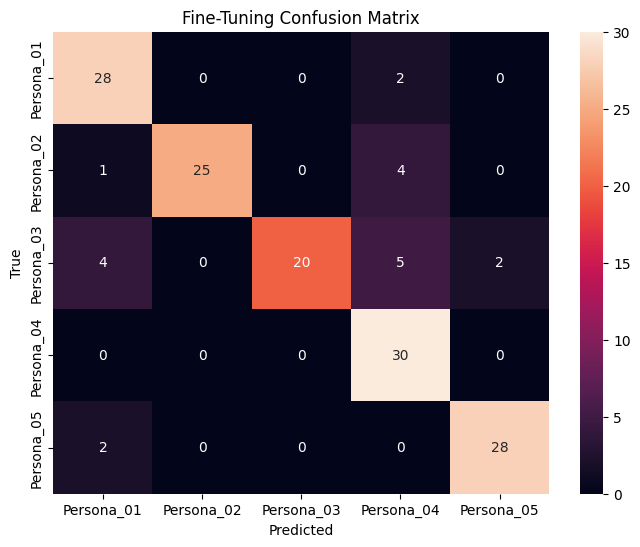

              precision    recall  f1-score   support

  Persona_01       0.80      0.93      0.86        30
  Persona_02       1.00      0.83      0.91        30
  Persona_03       1.00      0.65      0.78        31
  Persona_04       0.73      1.00      0.85        30
  Persona_05       0.93      0.93      0.93        30

    accuracy                           0.87       151
   macro avg       0.89      0.87      0.87       151
weighted avg       0.89      0.87      0.87       151



In [ ]:
# ============================================================
# FINAL EVALUATION
# ============================================================

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())

        all_labels.extend(labels.numpy())

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    xticklabels=class_names,

    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("True")

plt.title("Fine-Tuning Confusion Matrix")

plt.show()

# ============================================================
# REPORT
# ============================================================

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=class_names
    )
)

### **Profiling**

In [ ]:
# ============================================================
# TORCH PROFILER
# ============================================================

model.train()

imgs_p, labels_p = next(iter(train_loader))

with profiler.profile(

    activities=[

        profiler.ProfilerActivity.CPU,

        *(
            [profiler.ProfilerActivity.CUDA]
            if device.type == "cuda"
            else []
        ),
    ],

    record_shapes=True,

    profile_memory=True,

    with_flops=True,

) as prof:

    # --------------------------------------------------------
    # DATALOADER
    # --------------------------------------------------------

    with profiler.record_function(
        "0_dataloader"
    ):

        imgs_p, labels_p = next(iter(train_loader))

    # --------------------------------------------------------
    # HOST TO DEVICE
    # --------------------------------------------------------

    with profiler.record_function(
        "1_host_to_device"
    ):

        imgs_p = imgs_p.to(device)

        labels_p = labels_p.to(device)

    # --------------------------------------------------------
    # FORWARD
    # --------------------------------------------------------

    with profiler.record_function(
        "2_forward"
    ):

        optimizer.zero_grad()

        outputs = model(imgs_p)

    # --------------------------------------------------------
    # LOSS
    # --------------------------------------------------------

    with profiler.record_function(
        "3_loss"
    ):

        loss = criterion(
            outputs,
            labels_p
        )

    # --------------------------------------------------------
    # BACKWARD
    # --------------------------------------------------------

    with profiler.record_function(
        "4_backward"
    ):

        loss.backward()

    # --------------------------------------------------------
    # OPTIMIZER STEP
    # --------------------------------------------------------

    with profiler.record_function(
        "5_optimizer_step"
    ):

        optimizer.step()



/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


### **Profiler Table**

In [ ]:
print(

    prof.key_averages().table(

        sort_by="cpu_time_total",

        row_limit=20
    )
)

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  Total KFLOPs  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           0_dataloader         1.22%       2.728ms        71.61%     159.792ms     159.792ms       0.000us         0.00%       0.000us       0.000us      18.38 M

### **TRAINING BENTCHMARK: GPU VS CPU**

In [ ]:
# ============================================================
# TRAINING BENCHMARK CPU vs GPU
# ============================================================

import copy

training_results = []

for dev_name in ["cpu", "cuda"]:

    if dev_name == "cuda" and not torch.cuda.is_available():
        continue

    print("\n===================================")
    print(f"TRAINING BENCHMARK: {dev_name.upper()}")
    print("===================================")

    # --------------------------------------------------------
    # MODEL COPY
    # --------------------------------------------------------

    benchmark_model = copy.deepcopy(model)

    benchmark_model = benchmark_model.to(dev_name)

    benchmark_model.train()

    # --------------------------------------------------------
    # OPTIMIZER
    # --------------------------------------------------------

    optimizer_bench = optim.Adam(

        benchmark_model.parameters(),

        lr=1e-5
    )

    # --------------------------------------------------------
    # LIMITED ITERATIONS
    # --------------------------------------------------------

    benchmark_iterations = 20

    total_images = 0

    # ========================================================
    # CPU TIMING
    # ========================================================

    if dev_name == "cpu":

        start_time = time.time()

        for i, (images, labels) in enumerate(train_loader):

            if i >= benchmark_iterations:
                break

            images = images.to(dev_name)
            labels = labels.to(dev_name)

            optimizer_bench.zero_grad()

            outputs = benchmark_model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer_bench.step()

            total_images += images.size(0)

        end_time = time.time()

        total_time = end_time - start_time

    # ========================================================
    # GPU TIMING
    # ========================================================

    else:

        starter = torch.cuda.Event(
            enable_timing=True
        )

        ender = torch.cuda.Event(
            enable_timing=True
        )

        torch.cuda.synchronize()

        starter.record()

        for i, (images, labels) in enumerate(train_loader):

            if i >= benchmark_iterations:
                break

            images = images.to(dev_name)
            labels = labels.to(dev_name)

            optimizer_bench.zero_grad()

            outputs = benchmark_model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer_bench.step()

            total_images += images.size(0)

        ender.record()

        torch.cuda.synchronize()

        total_time = (
            starter.elapsed_time(ender)
            / 1000
        )

    # ========================================================
    # METRICS
    # ========================================================

    throughput = (
        total_images / total_time
    )

    avg_batch_time = (
        total_time / benchmark_iterations
    )

    print(
        f"Tiempo total training: "
        f"{total_time:.2f} s"
    )

    print(
        f"Tiempo promedio batch: "
        f"{avg_batch_time:.4f} s"
    )

    print(
        f"Training throughput: "
        f"{throughput:.2f} img/s"
    )

    training_results.append({

        "Device": dev_name.upper(),

        "Training Time (s)": round(
            total_time,
            2
        ),

        "Avg Batch Time (s)": round(
            avg_batch_time,
            4
        ),

        "Training Throughput": round(
            throughput,
            2
        )
    })


TRAINING BENCHMARK: CPU
Tiempo total training: 55.70 s
Tiempo promedio batch: 2.7850 s
Training throughput: 11.49 img/s

TRAINING BENCHMARK: CUDA
Tiempo total training: 3.17 s
Tiempo promedio batch: 0.1583 s
Training throughput: 202.10 img/s


### **Training Bentchmark Table**

In [ ]:
training_results_df = pd.DataFrame(
    training_results
)

display(training_results_df)

,Device,Training Time (s),Avg Batch Time (s),Training Throughput
0,CPU,55.70,2.7850,11.49
1,CUDA,3.17,0.1583,202.10


### **INFERENCE BENTCHMARK: GPU VS CPU**

In [ ]:
# ============================================================
# BENCHMARK DE INFERENCIA
# CPU vs GPU
# ============================================================

results = []

model.eval()

for dev_name in ["cpu", "cuda"]:

    # --------------------------------------------------------
    # VERIFY CUDA
    # --------------------------------------------------------

    if dev_name == "cuda" and not torch.cuda.is_available():
        continue

    device_bench = torch.device(dev_name)

    print("\n===================================")
    print(f"BENCHMARK: {device_bench}")
    print("===================================")

    # --------------------------------------------------------
    # MOVE MODEL
    # --------------------------------------------------------

    model = model.to(device_bench)

    # --------------------------------------------------------
    # INPUT DUMMY
    # --------------------------------------------------------

    dummy_input = torch.randn(
        1,
        3,
        224,
        224
    ).to(device_bench)

    # --------------------------------------------------------
    # WARMUP
    # --------------------------------------------------------

    with torch.no_grad():

        for _ in range(10):

            _ = model(dummy_input)

    if device_bench.type == "cuda":

        torch.cuda.synchronize()

    # --------------------------------------------------------
    # BENCHMARK
    # --------------------------------------------------------

    iterations = 100

    # ========================================================
    # TIMING CPU
    # ========================================================

    if device_bench.type == "cpu":

        start_time = time.time()

        with torch.no_grad():

            for _ in range(iterations):

                outputs = model(dummy_input)

        end_time = time.time()

        total_time = end_time - start_time

    # ========================================================
    # TIMING GPU CON CUDA EVENTS
    # ========================================================

    else:

        starter = torch.cuda.Event(
            enable_timing=True
        )

        ender = torch.cuda.Event(
            enable_timing=True
        )

        torch.cuda.synchronize()

        starter.record()

        with torch.no_grad():

            for _ in range(iterations):

                outputs = model(dummy_input)

        ender.record()

        torch.cuda.synchronize()

        # ----------------------------------------------------
        # milliseconds -> seconds
        # ----------------------------------------------------

        total_time = (
            starter.elapsed_time(ender)
            / 1000
        )

    # ========================================================
    # METRICS
    # ========================================================

    latency_ms = (
        total_time / iterations
    ) * 1000

    throughput = (
        iterations / total_time
    )

    # ========================================================
    # VRAM SOLO GPU
    # ========================================================

    if device_bench.type == "cuda":

        vram_mb = (
            torch.cuda.memory_allocated()
            / 1024**2
        )

    else:

        vram_mb = 0

    # ========================================================
    # SHOW RESULTS
    # ========================================================

    print(f"Latencia: {latency_ms:.2f} ms")

    print(f"Throughput: {throughput:.2f} img/s")

    print(f"VRAM: {vram_mb:.2f} MB")

    # ========================================================
    # SAVE RESULTS
    # ========================================================

    results.append({

        "Configuración": f"{dev_name.upper()} FP32",

        "Latencia (ms)": round(
            latency_ms,
            2
        ),

        "Throughput (img/s)": round(
            throughput,
            2
        ),

        "VRAM (MB)": round(
            vram_mb,
            2
        )
    })



**BENCHMARK: cpu**

Latencia: 53.20 ms

Throughput: 18.80 img/s

VRAM: 0.00 MB


**BENCHMARK: cuda**

Latencia: 10.37 ms

Throughput: 96.43 img/s

VRAM: 24.25 MB

### **OPTIMIZATION**

### **num_workers y pin_memory**

In [ ]:
# ============================================================
# DATALOADERS OPTIMIZADOS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True,

    # --------------------------------------------------------
    # MULTIPROCESAMIENTO
    # --------------------------------------------------------

    num_workers=2,

    # --------------------------------------------------------
    # OPTIMIZA CPU -> GPU
    # --------------------------------------------------------

    pin_memory=True,

    # --------------------------------------------------------
    # MANTIENE WORKERS ACTIVOS
    # --------------------------------------------------------

    persistent_workers=True
)

val_loader = DataLoader(

    val_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    persistent_workers=True
)

test_loader = DataLoader(

    test_dataset,

    batch_size=32,

    shuffle=False,

    num_workers=2,

    pin_memory=True,

    persistent_workers=True
)

# ============================================================
# CLASS NAMES
# ============================================================

class_names = train_dataset.classes

print(class_names)

Dataset copiado correctamente.
['Persona_01', 'Persona_02', 'Persona_03', 'Persona_04', 'Persona_05']


### **Profiling after Optimización**

In [ ]:
# ============================================================
# TORCH PROFILER OPTIMIZADO
# ============================================================

import torch
import torch.profiler as profiler
from torch.utils.data import DataLoader

# ============================================================
# DATALOADER OPTIMIZADO
# ============================================================

optimized_train_loader = DataLoader(

    train_dataset,

    batch_size=32,

    shuffle=True,

    # --------------------------------------------------------
    # OPTIMIZACIONES
    # --------------------------------------------------------

    num_workers=2,

    pin_memory=True,

    persistent_workers=True
)

# ============================================================
# MODEL TRAIN MODE
# ============================================================

model.train()

# ============================================================
# CREAR ITERATOR UNA SOLA VEZ
# IMPORTANTE:
# evita recrear workers
# ============================================================

optimized_iter = iter(
    optimized_train_loader
)

# ============================================================
# WARMUP
# IMPORTANTE:
# evita medir costo de inicialización
# ============================================================

for _ in range(3):

    imgs_p, labels_p = next(
        optimized_iter
    )

# ============================================================
# OBTENER BATCH REAL
# ============================================================

imgs_p, labels_p = next(
    optimized_iter
)

# ============================================================
# CUDA SYNC
# ============================================================

if device.type == "cuda":

    torch.cuda.synchronize()

# ============================================================
# PROFILER
# ============================================================

with profiler.profile(

    activities=[

        profiler.ProfilerActivity.CPU,

        *(
            [profiler.ProfilerActivity.CUDA]
            if device.type == "cuda"
            else []
        ),
    ],

    record_shapes=True,

    profile_memory=True,

    with_flops=True,

) as prof:

    # ========================================================
    # DATALOADER
    # ========================================================

    with profiler.record_function(
        "0_dataloader_optimized"
    ):

        imgs_p, labels_p = next(
            optimized_iter
        )

    # ========================================================
    # HOST -> DEVICE
    # ========================================================

    with profiler.record_function(
        "1_host_to_device_optimized"
    ):

        imgs_p = imgs_p.to(device)

        labels_p = labels_p.to(device)

    # ========================================================
    # FORWARD
    # ========================================================

    with profiler.record_function(
        "2_forward_optimized"
    ):

        optimizer.zero_grad()

        outputs = model(imgs_p)

    # ========================================================
    # LOSS
    # ========================================================

    with profiler.record_function(
        "3_loss_optimized"
    ):

        loss = criterion(
            outputs,
            labels_p
        )

    # ========================================================
    # BACKWARD
    # ========================================================

    with profiler.record_function(
        "4_backward_optimized"
    ):

        loss.backward()

    # ========================================================
    # OPTIMIZER STEP
    # ========================================================

    with profiler.record_function(
        "5_optimizer_step_optimized"
    ):

        optimizer.step()

# ============================================================
# CUDA SYNC
# ============================================================

if device.type == "cuda":

    torch.cuda.synchronize()

# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

print("\n")
print("=" * 70)
print("PROFILING OPTIMIZADO")
print("=" * 70)

print(

    prof.key_averages().table(

        sort_by=(

            "cuda_time_total"

            if device.type == "cuda"

            else "cpu_time_total"
        ),

        row_limit=20
    )
)



PROFILING OPTIMIZADO
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg       CPU Mem  Self CPU Mem      CUDA Mem  Self CUDA Mem    # of Calls  Total KFLOPs  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                 0_dataloader_optimized         0.06%     154.933us        67.51%     181.902ms     181.902ms           0 B           0 B           0 B           0 B             1            --  
enumerate(DataLoader)#_MultiProcessingDataLoaderIter...        65.86%     177.442ms        67.46%     181.747ms     181.747ms   